Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('../data/RTA Dataset.csv')

print("Dataset Loaded Successfully!")


Dataset Loaded Successfully!


Check Dataset Structure

In [3]:
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumns in dataset:")
print(df.columns.tolist())

Shape of dataset: (12316, 25)

First 5 rows:


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Vehicle_movement,Casualty_class,Sex_of_casualty,Cause_of_accident
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,Going straight,na,na,Moving Backward
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,Going straight,na,na,Overtaking
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,Going straight,Driver or rider,Male,Changing lane to the left
3,01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,Going straight,Pedestrian,Female,Changing lane to the right
4,01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,Going straight,na,na,Overtaking



Columns in dataset:
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Cause_of_accident']


Drop unwanted features

In [4]:
columns_to_drop = [
    'Age_band_of_driver',
    'Sex_of_driver',
    'Educational_level',
    'Vehicle_driver_relation',
    'Driving_experience',
    'Owner_of_vehicle',
    'Service_year_of_vehicle',
    'Sex_of_casualty',
    'Cause_of_accident',
    'Type_of_vehicle',
	'Defect_of_vehicle',
	'Road_allignment',
	'Road_surface_type',
	'Vehicle_movement',
]

# Drop only if they exist (safe)
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

In [5]:
# Check cleaned dataset
df.head()

print("\nFinal Shape:", df.shape)
print("\nRemaining Columns:\n", df.columns.tolist())


Final Shape: (12316, 11)

Remaining Columns:
 ['Time', 'Day_of_week', 'Area_accident_occured', 'Lanes_or_Medians', 'Types_of_Junction', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Casualty_class']


Check data types

In [6]:
print("\nData Types:\n")
print(df.dtypes)


Data Types:

Time                             str
Day_of_week                      str
Area_accident_occured            str
Lanes_or_Medians                 str
Types_of_Junction                str
Road_surface_conditions          str
Light_conditions                 str
Weather_conditions               str
Type_of_collision                str
Number_of_vehicles_involved    int64
Casualty_class                   str
dtype: object


Check remaining columns to get all unique values

In [7]:
columns_to_check = [
    'Day_of_week',
    'Area_accident_occured',
    'Lanes_or_Medians',
    'Types_of_Junction',
    'Road_surface_conditions',
    'Light_conditions',
    'Weather_conditions',
    'Casualty_class', 
    'Type_of_collision',
    'Number_of_vehicles_involved'
]

# Get unique values for selected columns
for col in columns_to_check:
    if col in df.columns:
        unique_vals = df[col].unique()
        print(f"🔹 Column: **{col}**")
        print(f"   Unique Count: {len(unique_vals)}")
        print("   Unique Values:")
        
        # Sort and print nicely
        for val in sorted(unique_vals, key=str):
            print(f"      - {val}")
        print("-" * 90 + "\n")
    else:
        print(f"Column '{col}' not found in dataset!\n")

🔹 Column: **Day_of_week**
   Unique Count: 7
   Unique Values:
      - Friday
      - Monday
      - Saturday
      - Sunday
      - Thursday
      - Tuesday
      - Wednesday
------------------------------------------------------------------------------------------

🔹 Column: **Area_accident_occured**
   Unique Count: 15
   Unique Values:
      -   Market areas
      -   Recreational areas
      -  Church areas
      -  Hospital areas
      -  Industrial areas
      -  Outside rural areas
      - Office areas
      - Other
      - Recreational areas
      - Residential areas
      - Rural village areas
      - Rural village areasOffice areas
      - School areas
      - Unknown
      - nan
------------------------------------------------------------------------------------------

🔹 Column: **Lanes_or_Medians**
   Unique Count: 8
   Unique Values:
      - Double carriageway (median)
      - One way
      - Two-way (divided with broken lines road marking)
      - Two-way (divided with s

Overview

In [8]:
# General info
df.info()

# Summary statistics (for numeric columns)
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Area_accident_occured        12077 non-null  str  
 3   Lanes_or_Medians             11931 non-null  str  
 4   Types_of_Junction            11429 non-null  str  
 5   Road_surface_conditions      12316 non-null  str  
 6   Light_conditions             12316 non-null  str  
 7   Weather_conditions           12316 non-null  str  
 8   Type_of_collision            12161 non-null  str  
 9   Number_of_vehicles_involved  12316 non-null  int64
 10  Casualty_class               12316 non-null  str  
dtypes: int64(1), str(10)
memory usage: 1.0 MB


,Time,Day_of_week,Area_accident_occured,Lanes_or_Medians,Types_of_Junction,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Casualty_class
count,12316,12316,12077,11931,11429,12316,12316,12316,12161,12316.000000,12316
unique,1074,7,14,7,8,4,4,9,10,NaN,4
top,15:30:00,Friday,Other,Two-way (divided with broken lines road marking),Y Shape,Dry,Daylight,Normal,Vehicle with vehicle collision,NaN,Driver or rider
freq,120,2041,3819,4411,4543,9340,8798,10063,8774,NaN,4944
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.040679,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.688790,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN


Check Missing Values

In [9]:
# Count missing values per column
missing_values = df.isnull().sum()

# Show only columns with missing values
missing_values[missing_values > 0]

Area_accident_occured    239
Lanes_or_Medians         385
Types_of_Junction        887
Type_of_collision        155
dtype: int64

Visualize Missing Values

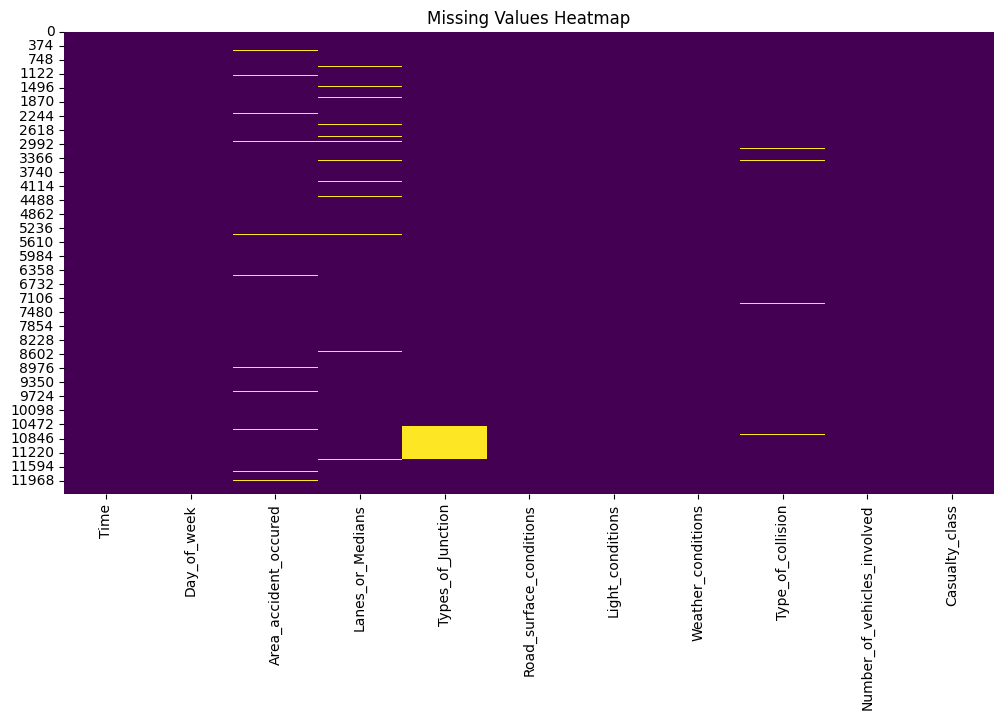

In [10]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

Remove Rows with Missing Target (Casualty_class + Type_of_collision + Number_of_vehicles_involved)

In [11]:
# Remove rows with missing values in Type_of_collision
df = df.dropna(subset=['Type_of_collision'])

In [12]:
df.shape

(12161, 11)

Check missing values

In [13]:
# Count missing values per column
missing_values = df.isnull().sum()

# Show only columns with missing values
missing_values

Time                             0
Day_of_week                      0
Area_accident_occured          238
Lanes_or_Medians               381
Types_of_Junction              872
Road_surface_conditions          0
Light_conditions                 0
Weather_conditions               0
Type_of_collision                0
Number_of_vehicles_involved      0
Casualty_class                   0
dtype: int64

Handle Missing Feature Values

In [14]:
# Replace all remaining NaN values
df = df.fillna("Unknown")

Verify Cleaning

In [15]:
# Check again for missing values
df.isnull().sum()

Time                           0
Day_of_week                    0
Area_accident_occured          0
Lanes_or_Medians               0
Types_of_Junction              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Casualty_class                 0
dtype: int64

Final Check

In [16]:
# Check cleaned dataset
df.head()

print("\nFinal Shape:", df.shape)
print("\nRemaining Columns:\n", df.columns.tolist())


Final Shape: (12161, 11)

Remaining Columns:
 ['Time', 'Day_of_week', 'Area_accident_occured', 'Lanes_or_Medians', 'Types_of_Junction', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Casualty_class']


Get all combinations

In [17]:
# Get combinations with counts
combinations = df.groupby(['Casualty_class', 
                           'Type_of_collision', 
                           'Number_of_vehicles_involved']).size().reset_index(name='Count')

# Sort by frequency (most common first)
combinations = combinations.sort_values(by='Count', ascending=False)

# Display all combinations
print(f"Total Unique Combinations: {len(combinations)}\n")
print(combinations.to_string(index=False))

Total Unique Combinations: 132

 Casualty_class                       Type_of_collision  Number_of_vehicles_involved  Count
Driver or rider          Vehicle with vehicle collision                            2   2321
             na          Vehicle with vehicle collision                            2   2141
     Pedestrian          Vehicle with vehicle collision                            2    816
      Passenger          Vehicle with vehicle collision                            2    624
Driver or rider          Vehicle with vehicle collision                            1    589
Driver or rider         Collision with roadside objects                            2    542
             na          Vehicle with vehicle collision                            1    505
Driver or rider          Vehicle with vehicle collision                            3    456
             na          Vehicle with vehicle collision                            3    441
             na         Collision with roadside 

In [13]:
print("Casualty_class value counts:")
print(df['Casualty_class'].value_counts(dropna=False))

Casualty_class value counts:
Casualty_class
Driver or rider    4944
na                 4443
Pedestrian         1649
Passenger          1280
Name: count, dtype: int64


In [14]:
# Define mapping for Casualty_class to Risk
risk_map = {
    'No injury': 'Low',
    'Minor injury': 'Low',
    'Driver or rider': 'Medium',
    'Passenger': 'Medium',
    'Pedestrian': 'High'
}

df['Risk'] = df['Casualty_class'].map(risk_map).fillna('Low')  # Default to Low if not found

print(df[['Casualty_class', 'Risk']].head(10))
print("\nRisk value counts:")
print(df['Risk'].value_counts())

    Casualty_class    Risk
0               na     Low
1               na     Low
2  Driver or rider  Medium
3       Pedestrian    High
4               na     Low
5  Driver or rider  Medium
6  Driver or rider  Medium
7               na     Low
8       Pedestrian    High
9        Passenger  Medium

Risk value counts:
Risk
Medium    6224
Low       4443
High      1649
Name: count, dtype: int64


In [15]:
# Convert Time to Time of Day bins
def get_time_of_day(t):
    if t == "Unknown" or pd.isnull(t):
        return "Unknown"
    hour = int(str(t).split(":")[0])
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df['Time_of_day'] = df['Time'].apply(get_time_of_day)

# Simplify Weather_conditions
weather_map = {
    'Normal': 'Clear',
    'Cloudy': 'Cloudy',
    'Rain': 'Rain',
    'Windy': 'Windy',
    'Fog': 'Fog',
    'Unknown': 'Unknown'
}
df['Weather_simple'] = df['Weather_conditions'].map(lambda x: weather_map.get(x, 'Other'))

# Simplify Road_surface_conditions
road_cond_map = {
    'Dry': 'Dry',
    'Wet or damp': 'Wet',
    'Snow': 'Snow',
    'Flood over 3cm. deep': 'Flood',
    'Unknown': 'Unknown'
}
df['Road_cond_simple'] = df['Road_surface_conditions'].map(lambda x: road_cond_map.get(x, 'Other'))

# Check new features
print(df[['Time', 'Time_of_day', 'Weather_conditions', 'Weather_simple', 'Road_surface_conditions', 'Road_cond_simple']].head())

       Time Time_of_day Weather_conditions Weather_simple  \
0  17:02:00     Evening             Normal          Clear   
1  17:02:00     Evening             Normal          Clear   
2  17:02:00     Evening             Normal          Clear   
3  01:06:00       Night             Normal          Clear   
4  01:06:00       Night             Normal          Clear   

  Road_surface_conditions Road_cond_simple  
0                     Dry              Dry  
1                     Dry              Dry  
2                     Dry              Dry  
3                     Dry              Dry  
4                     Dry              Dry  


In [16]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Select features for the model (only those available before/during driving)
features = [
    'Time_of_day', 'Day_of_week', 'Weather_simple', 'Road_cond_simple',
    'Area_accident_occured', 'Junction_type', 'Type_of_vehicle',
    'Road_surface_type', 'Light_conditions', 'Type_of_collision',
    'Number_of_vehicles_involved', 'Vehicle_movement', 'Lane_type', 'Road_allignment', 'Road_profile', 'Lane/Median'
]

# Keep only features that exist in the dataframe
features = [f for f in features if f in df.columns]

X = df[features]
y = df['Risk']

# One-hot encode categorical features
ohe = OneHotEncoder(handle_unknown='ignore')
X_encoded = ohe.fit_transform(X).toarray()

# Encode target variable
y_le = LabelEncoder()
y_encoded = y_le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Feature shape after encoding:", X_train.shape)
print("Target classes:", y_le.classes_)

Feature shape after encoding: (9852, 101)
Target classes: ['High' 'Low' 'Medium']


In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define ANN model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(y_le.classes_), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

print("Model training complete.")

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4955 - loss: 0.9924 - val_accuracy: 0.5150 - val_loss: 0.9854
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5035 - loss: 0.9796 - val_accuracy: 0.5140 - val_loss: 0.9851
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5054 - loss: 0.9734 - val_accuracy: 0.5124 - val_loss: 0.9874
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5111 - loss: 0.9680 - val_accuracy: 0.5003 - val_loss: 0.9905
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5176 - loss: 0.9597 - val_accuracy: 0.5058 - val_loss: 0.9936
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5268 - loss: 0.9511 - val_accuracy: 0.4921 - val_loss: 0.9997
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5323 - loss: 0.9392 - val_accuracy: 0.4977 - val_loss: 1.0062
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5372 - loss: 0.9268 - val_accuracy: 0.

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step
Accuracy: 0.4346590909090909

Classification Report:
               precision    recall  f1-score   support

        High       0.10      0.05      0.07       330
         Low       0.37      0.38      0.37       889
      Medium       0.52      0.58      0.55      1245

    accuracy                           0.43      2464
   macro avg       0.33      0.33      0.33      2464
weighted avg       0.41      0.43      0.42      2464



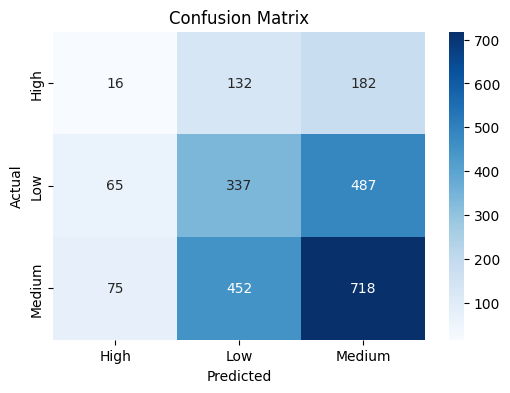

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print("\nClassification Report:\n", classification_report(y_test, y_pred_classes, target_names=y_le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_le.classes_, yticklabels=y_le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

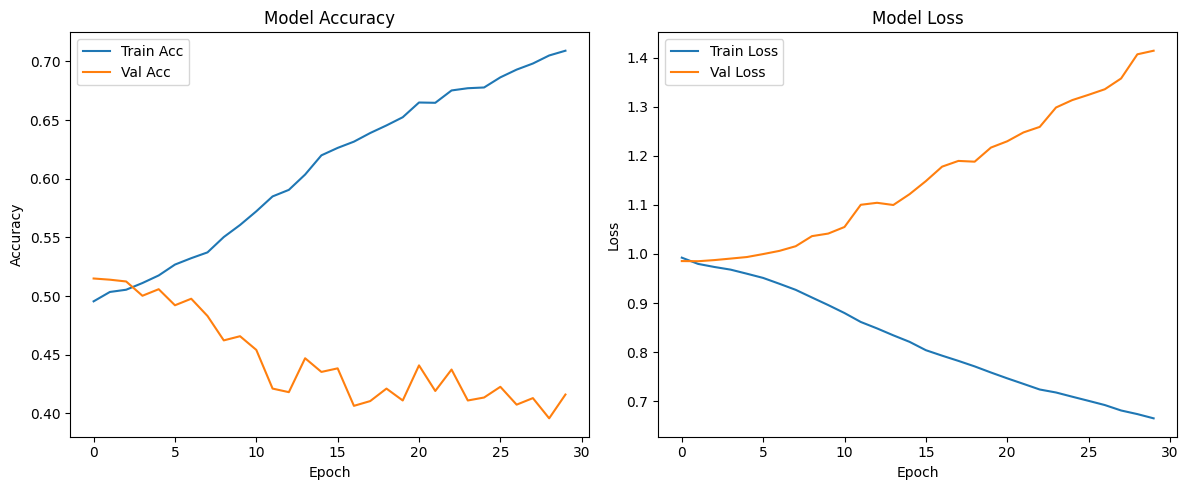

In [19]:
# Plot training & validation accuracy/loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Example: Predict risk for a new scenario
# (Night, Rain, Highway, etc.)
sample = pd.DataFrame({
    'Time_of_day': ['Night'],
    'Day_of_week': ['Monday'],
    'Weather_simple': ['Rain'],
    'Road_cond_simple': ['Wet'],
    'Area_accident_occured': ['Urban'],
    'Junction_type': ['Yes'],
    'Type_of_vehicle': ['Automobile'],
    'Road_surface_type': ['Asphalt roads'],
    'Light_conditions': ['Darkness - lights lit'],
    'Type_of_collision': ['Vehicle with vehicle collision'],
    'Number_of_vehicles_involved': [2],
    'Vehicle_movement': ['Going straight'],
    'Lane_type': ['Single'],
    'Road_allignment': ['Straight'],
    'Road_profile': ['Flat'],
    'Lane/Median': ['None']
})

# Keep only columns present in training
test_features = [f for f in features if f in sample.columns]
sample = sample[test_features]
sample_encoded = ohe.transform(sample)
pred = model.predict(sample_encoded)
pred_class = y_le.inverse_transform([np.argmax(pred)])
print(f"Predicted Risk Level: {pred_class[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predicted Risk Level: High


## Test with Sample Inputs (Simulation)
Let’s simulate a real-world prediction using the trained model.

## Visualize Training History
We will plot the training and validation accuracy and loss curves to check for overfitting and model convergence.

## Evaluate Model Performance
We will now evaluate the model using accuracy, precision, recall, F1-score, and confusion matrix.

## Build and Train the ANN Model
We will use Keras (TensorFlow) to build a simple feedforward neural network for classification.

## Encode Categorical Features & Prepare Data for ANN
We will encode categorical variables using one-hot encoding and scale numeric features if needed. The target variable will be encoded as well.

## Feature Engineering
We will now engineer features to make the data more suitable for machine learning. This includes:
- Converting time to time-of-day bins (morning, afternoon, evening, night)
- Simplifying weather and road categories
- Dropping or merging rare categories if needed

## Map Casualty_class to Risk Levels
We map the `Casualty_class` to risk categories as follows:
- **Low**: No injury / Minor
- **Medium**: Driver / Passenger
- **High**: Pedestrian

This mapping is based on the severity of accident outcomes, using `Casualty_class` as a proxy for risk.